In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

2022-09-05 18:47:12.593753: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-09-05 18:47:12.593786: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
crypto_currency = "BTC"
against_currency = "USD"
prediction_days = 60

In [3]:

# getting the data or price of bitcoin
start = dt.datetime(2016, 1, 1)
end = dt.datetime.now()

data = web.DataReader(f"{crypto_currency}-{against_currency}", "yahoo", start, end)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data["Close"].values.reshape(-1, 1))

In [4]:
data

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2016-01-01,436.246002,427.515015,430.721008,434.334015,36278900,434.334015
2016-01-02,436.062012,431.869995,434.622009,433.437988,30096600,433.437988
2016-01-03,433.743011,424.705994,433.578003,430.010986,39633800,430.010986
2016-01-04,434.516998,429.084015,430.061005,433.091003,38477500,433.091003
2016-01-05,434.182007,429.675995,433.069000,431.959991,34522600,431.959991
...,...,...,...,...,...,...
2022-09-01,20198.390625,19653.968750,20050.498047,20127.140625,30182031010,20127.140625
2022-09-02,20401.568359,19814.765625,20126.072266,19969.771484,29123998928,19969.771484
2022-09-03,20037.009766,19698.355469,19969.718750,19832.087891,23613051457,19832.087891


In [5]:
# spliting the data in x and y train
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x - prediction_days : x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [6]:
# creating the neural network
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=25, batch_size=32)

2022-09-05 18:47:23.489482: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-09-05 18:47:23.489535: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-09-05 18:47:23.489562: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (codespaces-af4c92): /proc/driver/nvidia/version does not exist
2022-09-05 18:47:23.490269: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/25
75/75 [==============================] - 11s 77ms/step - loss: 0.0068
Epoch 2/25
75/75 [==============================] - 6s 76ms/step - loss: 0.0025
Epoch 3/25
75/75 [==============================] - 6s 77ms/step - loss: 0.0027
Epoch 4/25
75/75 [==============================] - 6s 76ms/step - loss: 0.0022
Epoch 5/25
75/75 [==============================] - 6s 77ms/step - loss: 0.0021
Epoch 6/25
75/75 [==============================] - 6s 78ms/step - loss: 0.0019
Epoch 7/25
75/75 [==============================] - 6s 76ms/step - loss: 0.0018
Epoch 8/25
75/75 [==============================] - 6s 79ms/step - loss: 0.0018
Epoch 9/25
75/75 [==============================] - 6s 76ms/step - loss: 0.0018
Epoch 10/25
75/75 [==============================] - 6s 77ms/step - loss: 0.0014
Epoch 11/25
75/75 [==============================] - 6s 77ms/step - loss: 0.0016
Epoch 12/25
75/75 [==============================] - 6s 77ms/step - loss: 0.0018
Epoch 13/25
75/75 [=================

In [7]:
# getting the actual price of btc
test_start = dt.datetime(2020, 1, 1)
test_end = dt.datetime.now()
test_data = web.DataReader(f"{crypto_currency}-{against_currency}", "yahoo", test_start, test_end)
actual_prices = test_data["Close"].values

total_dataset = pd.concat((data["Close"], test_data["Close"]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.fit_transform(model_inputs)

In [8]:
# spliting the data and predicting 
x_test = []

for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x - prediction_days : x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

prediction_prices = model.predict(x_test)
prediction_prices = scaler.inverse_transform(prediction_prices)

31/31 [==============================] - 2s 19ms/step


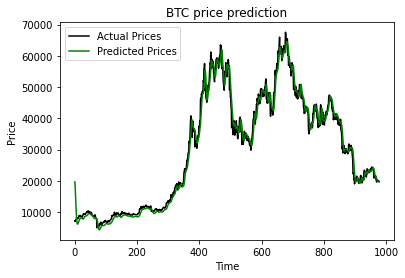

In [9]:
# ploting the result 
plt.plot(actual_prices, color="black", label="Actual Prices")
plt.plot(prediction_prices, color="green", label="Predicted Prices")
plt.title(f"{crypto_currency} price prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(loc="upper left")
plt.show()

In [10]:
# saving the model 
model.save('btc_price_prediction.h5')

In [11]:
# spliting the data to predict next day
real_data = [model_inputs[len(model_inputs) + 1 - prediction_days : len(model_inputs)+1,0]]
real_data = np.array(real_data)
real_data = np.reshape(real_data,(real_data.shape[0],real_data.shape[1],1))

In [12]:
# predicting the next day
prediction = model.predict(real_data)
prediction = scaler.inverse_transform(prediction)
prediction

1/1 [==============================] - 1s 916ms/step


array([[19671.121]], dtype=float32)